In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns


In [2]:

foods = pd.read_csv(
    "FoodData_Central_branded_food_csv_2026-04-30/food.csv",
    low_memory= False
)

nutrients = pd.read_csv(
    "FoodData_Central_branded_food_csv_2026-04-30/food_nutrient.csv",
    low_memory= False
)


foods.columns = foods.columns.str.strip()

protein = nutrients[nutrients['nutrient_id'] == 1003][['fdc_id', 'amount']]
calories = nutrients[nutrients['nutrient_id'] == 1008][['fdc_id', 'amount']]

nutrition = pd.merge(protein, calories, on="fdc_id")

df = pd.merge(
    foods[['fdc_id', 'description']],
    nutrition,
    on="fdc_id"
)


df = df.dropna()

df['amount_x'] = pd.to_numeric(df['amount_x'], errors='coerce')
df['amount_y'] = pd.to_numeric(df['amount_y'], errors='coerce')

df = df.dropna()

df = df[df['amount_x'] > 0]
df = df[df['amount_y'] > 0]
df = df[df['amount_x'] < 100]
df = df[df['amount_y'] < 2000]

df = df.reset_index(drop = True)
df = df.drop_duplicates(subset = 'description', keep = 'first')


df['protein_efficiency'] = df['amount_x'] / df['amount_y']

top10 = df.sort_values(by= 'protein_efficiency', ascending = False).head(10)

top10 = top10.reset_index(drop =True)
top10.index = top10.index + 1

defined = top10.rename( columns = {
    'amount_x': 'protein_g',
    'amount_y': 'calories_kcal'
})

print("Top 10 Branded High Protein and Low Calorie Foods:")
print(defined[['description', 'protein_g', 'calories_kcal', 'protein_efficiency']])





Top 10 Branded High Protein and Low Calorie Foods:
                                          description  protein_g  \
1                       CRUNCHY PEANUT BUTTER, PEANUT      21.88   
2   PEPPER JACK CHEESE HARD-BOILED EGG, GENOA SALA...      20.22   
3                      Creamette 16 Oz Rigatoni Pasta      12.50   
4              Creamette 16 Oz Spaghetti Rigate Pasta      12.50   
5   PANKO BUTTERFLY CRISPY SEASONED SHRIMP, PANKO ...      11.90   
6                          ORIGINAL DRY RUB, ORIGINAL      40.91   
7                              GARLIC DRY RUB, GARLIC      40.91   
8   365 by Whole Foods Market Organic Whole Milk, ...       8.00   
9   Tillamook Farmstyle Colby Jack Cheese Slices -...       8.00   
10  PARMESAN CRUSTED TILAPIA WITH FINGERLING POTAT...      11.90   

    calories_kcal  protein_efficiency  
1             3.0            7.293333  
2             3.0            6.740000  
3             2.0            6.250000  
4             2.0            6.250000  


In [ ]:
worst10 = df.sort_values(by = 'protein_efficiency').head(10)

worst10 = worst10.reset_index(drop= True)
worst10.index = worst10.index + 1

print("Top 10 Worst Protien Efficiency Foods:")
print(worst10[['description', 'protein_efficiency']])

Top 10 Worst Protien Efficiency Foods:
                                          description  protein_efficiency
1                                      ORIGINAL SNACK            0.000018
2   Betty Crocker Oreo Creme Flavored Whipped Fros...            0.000022
3                       MALANG COW SOFT CHEWING CANDY            0.000023
4                       Gold Medal Cream Cheese Icing            0.000024
5                      Gold Medal Vanilla Creme Icing            0.000024
6         IMITATION STRAWBERRY MUFFIN MIX, STRAWBERRY            0.000024
7                  CRANBERRY CINNAMON SWIRL DEMI LOAF            0.000027
8                 JENNY LEE, RUM RAISIN HOLIDAY BREAD            0.000027
9   CRANBERRY CINNAMON SWIRL DEMI LOAF, CRANBERRY ...            0.000027
10                            MUSHROOM VIETNAMESE PHO            0.000027


In [ ]:
highest_protein = defined.sort_values(by = 'protein_g', ascending = False).head(10)


highest_protein = highest_protein.reset_index (drop = True)
highest_protein.index = highest_protein.index + 1

print("\nHighest Protein Foods:\n")
print(highest_protein[['description', 'protein_g', 'calories_kcal']])


Highest Protein Foods:

                                          description  protein_g  \
1                          ORIGINAL DRY RUB, ORIGINAL      40.91   
2                              GARLIC DRY RUB, GARLIC      40.91   
3                       CRUNCHY PEANUT BUTTER, PEANUT      21.88   
4   PEPPER JACK CHEESE HARD-BOILED EGG, GENOA SALA...      20.22   
5                      Creamette 16 Oz Rigatoni Pasta      12.50   
6              Creamette 16 Oz Spaghetti Rigate Pasta      12.50   
7   PANKO BUTTERFLY CRISPY SEASONED SHRIMP, PANKO ...      11.90   
8   PARMESAN CRUSTED TILAPIA WITH FINGERLING POTAT...      11.90   
9   365 by Whole Foods Market Organic Whole Milk, ...       8.00   
10  Tillamook Farmstyle Colby Jack Cheese Slices -...       8.00   

    calories_kcal  
1             8.0  
2             8.0  
3             3.0  
4             3.0  
5             2.0  
6             2.0  
7             2.0  
8             3.0  
9             2.0  
10            2.0  


In [52]:
connect = defined[['protein_g', 'calories_kcal', 'protein_efficiency']].corr()

print ("\nHow these catagories Correlate:\n")
print(connect)


How these catagories Correlate:

                    protein_g  calories_kcal  protein_efficiency
protein_g            1.000000       0.966836            0.151967
calories_kcal        0.966836       1.000000           -0.100636
protein_efficiency   0.151967      -0.100636            1.000000


In [ ]:
defined = df.copy()

def categorize(text):
    
    text = str(text).lower()

    if any(word in text for word in ["chicken", "beef", "turkey", "pork", "steak", "jerky"]):

        return "Meat"
    elif any(word in text for word in  ["milk", "cheese", "yogurt", "cream"]):

        return "Dairy"
    elif any(word in text for word in ["tofu", "soy", "bean", "lentil"]):

        return "Plant-Based"
    elif any(word in text for word in ["peanut", "almond", "cashew"]):

        return "Nut-Based"
    elif any(word in text for word in ["bar", "snack", "chip", "cracker"]):

        return "Snack"
    elif any(word in text for word in  ["drink", "juice", "beverage", "shake"]):

        return "Beverage"
    
    elif "protein" in text:
        return "Protein Product"
    
    elif any(word in text for word in ["pizza", "pasta", "meal", "chili", "rice"]):

        return "Prepared Food"
    else:
        return "Other"



defined['category'] =  defined['description'].apply(categorize)

category =  defined.groupby('category')['protein_efficiency'].mean().sort_values(ascending=False)



print("\nAverage Protein Efficiency by Category:\n")
print(category)


Average Protein Efficiency by Category:

category
Protein Product    0.116856
Meat               0.083201
Plant-Based        0.054319
Beverage           0.043395
Dairy              0.041539
Other              0.037420
Prepared Food      0.031958
Nut-Based          0.031888
Snack              0.023980
Name: protein_efficiency, dtype: float64


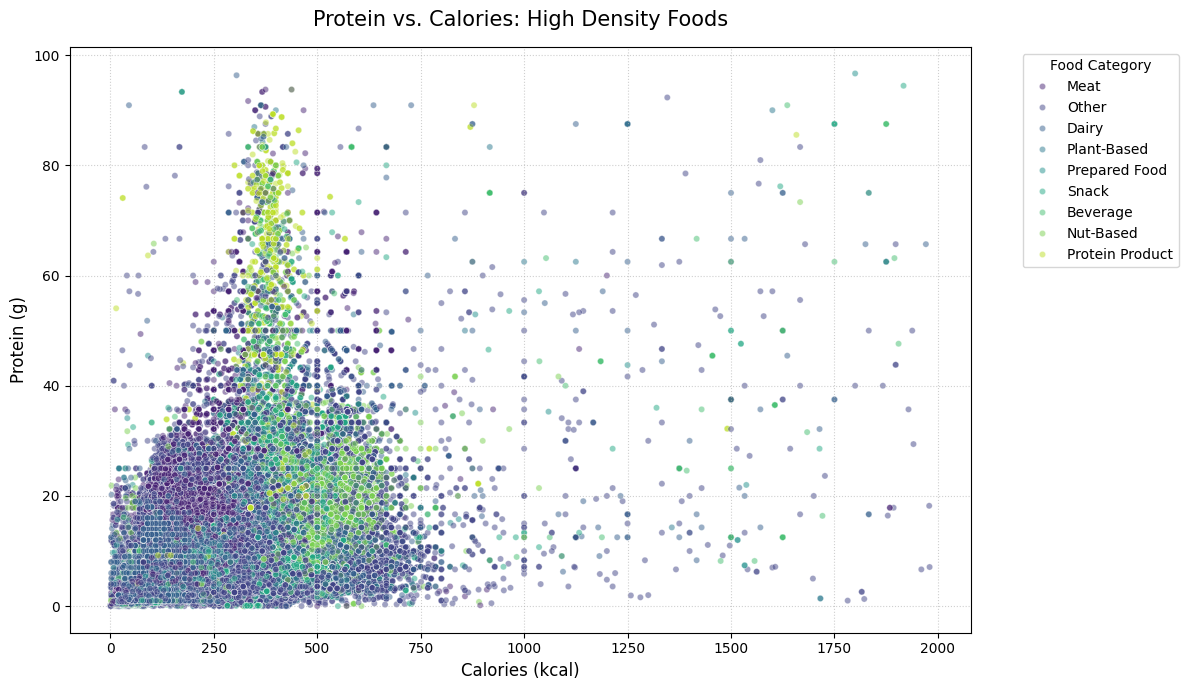

In [66]:
if 'category' not in df.columns:
    df['category'] = df['description'].apply(categorize)



x_name = 'calories' if 'calories' in df.columns else 'amount_y'
y_name = 'protein' if 'protein' in df.columns else 'amount_x'


plt.figure(figsize=(12, 7))


sns.scatterplot(
    data=df, 
    x=x_name, 
    y=y_name, 
    hue='category', 
    alpha=0.5, 
    s=20,
    palette='viridis' # Makes the colors look a bit more modern
)

plt.title("Protein vs. Calories: High Density Foods", fontsize=15, pad=15)
plt.xlabel("Calories (kcal)", fontsize=12)
plt.ylabel("Protein (g)", fontsize=12)

plt.legend(title='Food Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

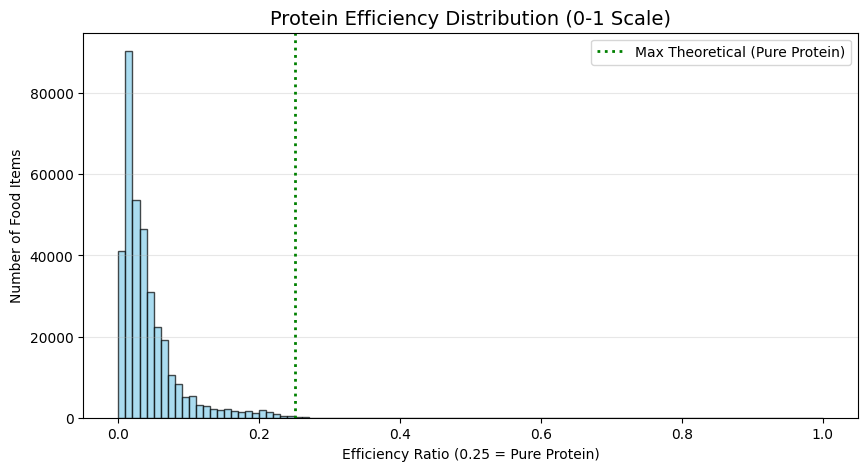

In [68]:
plt.figure(figsize=(10, 5))


plt.hist(df['protein_efficiency'], bins=100, range=(0, 1), color='skyblue', edgecolor='black', alpha=0.7)

plt.axvline(0.25, color='green', linestyle=':', linewidth=2, label='Max Theoretical (Pure Protein)')


plt.title("Protein Efficiency Distribution (0-1 Scale)", fontsize=14)
plt.xlabel("Efficiency Ratio (0.25 = Pure Protein)")
plt.ylabel("Number of Food Items")

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

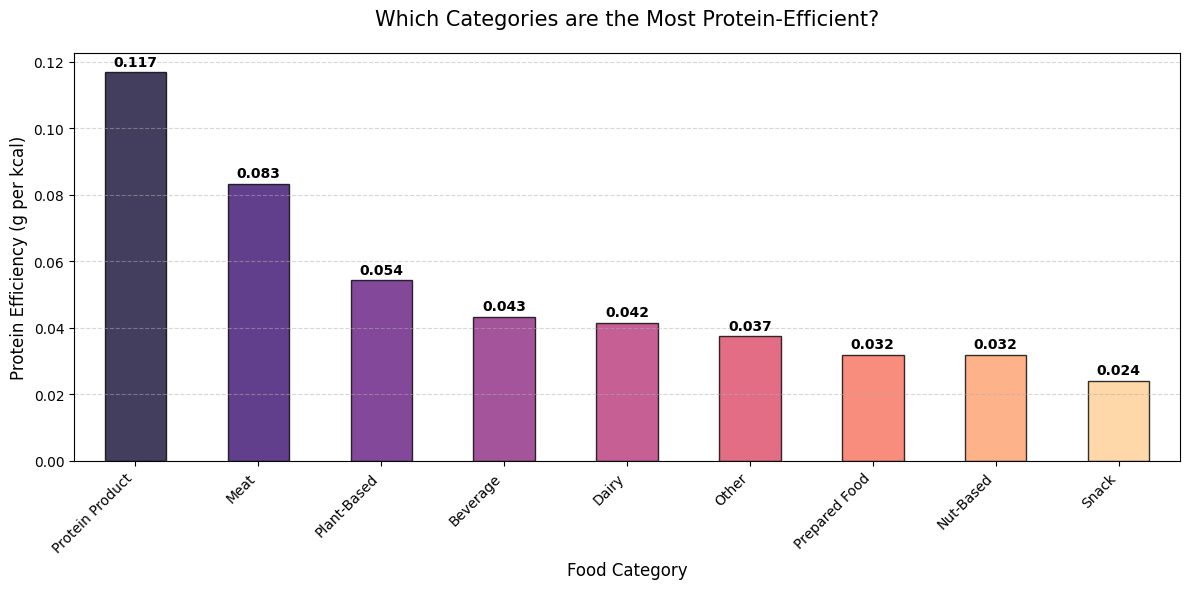

In [70]:
plt.figure(figsize=(12, 6))

colors = sns.color_palette("magma", len(category))
ax = category.plot(kind='bar', color=colors, edgecolor='black', alpha=0.8)

for i, v in enumerate(category):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')

plt.title("Which Categories are the Most Protein-Efficient?", fontsize=15, pad=20)
plt.ylabel("Protein Efficiency (g per kcal)", fontsize=12)
plt.xlabel("Food Category", fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout() 
plt.show()

LINEAR MODEL RESULTS
Slope (Protein per Calorie): 0.0149
Intercept (Base Protein):    5.2484
Interpretation: For every 100 calories, you average 1.5g of protein.


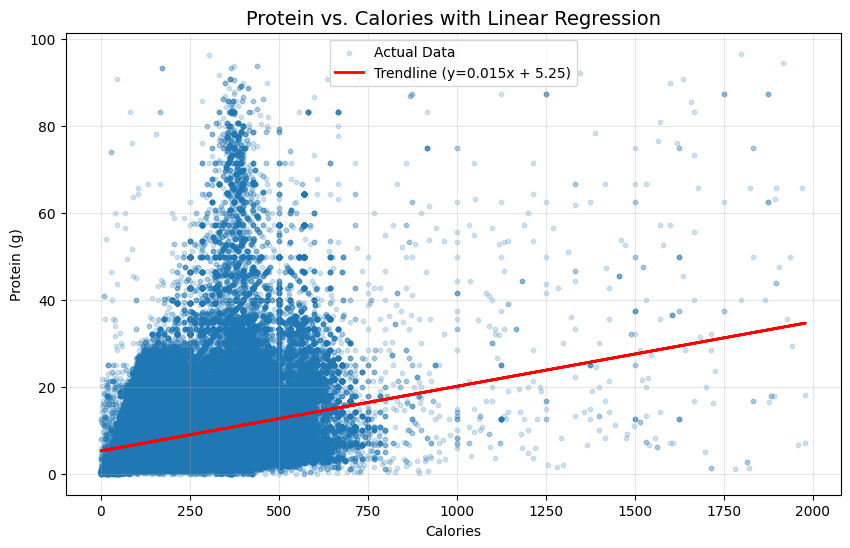

In [72]:
x_name = 'calories' if 'calories' in df.columns else 'amount_y'
y_name = 'protein' if 'protein' in df.columns else 'amount_x'

x = df[x_name].values
y = df[y_name].values


m, b = np.polyfit(x, y, 1)

print("LINEAR MODEL RESULTS")
print(f"Slope (Protein per Calorie): {m:.4f}")
print(f"Intercept (Base Protein):    {b:.4f}")
print(f"Interpretation: For every 100 calories, you average {m*100:.1f}g of protein.")


plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.2, label='Actual Data', s=10)


plt.plot(x, m*x + b, color='red', linewidth=2, label=f'Trendline (y={m:.3f}x + {b:.2f})')

plt.title("Protein vs. Calories with Linear Regression", fontsize=14)
plt.xlabel("Calories")
plt.ylabel("Protein (g)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [73]:
y_predict = m * x + b

plot_total = np.sum((y - np.mean(y))**2)  
plot_res = np.sum((y - y_predict)**2)

r2 = 1 - (plot_res / plot_total)

print("MODEL ACCURACY SUMMARY")


print(f"R² Score: {r2:.4f}")

if r2 > 0.7:
    
    print("Interpretation: Strong correlation. Calories are a good predictor of protein content.")
elif r2 > 0.4:

    print("Interpretation: Moderate correlation. Other factors (like food category) matter a lot.")
else:

    print("Interpretation: Weak correlation. Protein content varies wildly regardless of calorie count.")


residuals = y - y_predict
print(f"\nMax Over-prediction: {np.min(residuals):.2f}g protein")
print(f"Max Under-prediction: {np.max(residuals):.2f}g protein")


MODEL ACCURACY SUMMARY
R² Score: 0.0769
Interpretation: Weak correlation. Protein content varies wildly regardless of calorie count.

Max Over-prediction: -31.03g protein
Max Under-prediction: 86.56g protein
